## Value Iteration using KotlinRL Maze Env

In [1]:
USE {
    repositories {
        mavenCentral()
        maven("https://central.sonatype.com/repository/maven-snapshots/")
    }
    dependencies {
        implementation("io.github.kotlinrl:envs:0.1.0-SNAPSHOT")
    }
}
%use lets-plot

In [2]:
import io.github.kotlinrl.core.*
import io.github.kotlinrl.envs.*

Let's set up our testing parameters.  There is no training with value iteration.  The ```Value Iteration Algorithm``` works against a Model Based Environment to calculate the best ```Policy``` for the agent.

In [3]:
val testEpisodes = 3
val stateActionListProvider = StateActionListProvider<IntArray, Int> { listOf(0, 1, 2, 3) }
val stateShape = intArrayOf(5, 5)
val pTable = PTable(stateShape)
val vTable = VTable(stateShape)


In [4]:
val env = Maze(render = true)
val testingAgent = agent(
    id = "testing",
    policy = valueIteration(
        env = env,
        pTable = pTable,
        vTable = vTable,
        stateActionListProvider = stateActionListProvider
    ),
)

In [ ]:
println("Testing agent:")
val recordEnv = RecordVideo(env, folder = "videos/maze_value_iteration")
val trainer = episodicTrainer(
    agent = testingAgent,
    env = recordEnv,
)
val testResults = trainer.train(testEpisodes)
println("Test results: ${testResults.episodeRewards}")
repeat(testEpisodes) {
    displayVideo(
        episode = it + 1,
        folder = recordEnv.folder,
    )
}


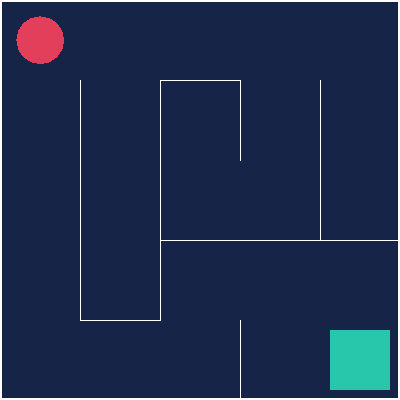

In [17]:
import java.io.File
import javax.imageio.ImageIO
import java.awt.image.BufferedImage

val image: BufferedImage = ImageIO.read(File(File(recordEnv.folder, "episode_1"), "frame_01.png"))

fun buildStateValuePolicyData(): Map<String, List<Any>> {
    val actionSymbols: Map<Int, String> = mapOf(
        0 to "↑", 1 to "→", 2 to "↓", 3 to "←"
    )

    val x = mutableListOf<Int>()
    val y = mutableListOf<Int>()
    val value = mutableListOf<Double>()
    val action = mutableListOf<String>()

    val shape = vTable.shape
    for (row in 0 until shape[0]) {
        for (col in 0 until shape[1]) {
            val state = intArrayOf(row, col)
            x += col
            y += -row  // Flip Y for top-down rendering
            value += (vTable[state] * 100).roundToInt() / 100.0
            action += actionSymbols[pTable[state]] ?: "?"
        }
    }

    return mapOf(
        "x" to x,
        "y" to y,
        "value" to value,
        "action" to action
    )
}

val data = buildStateValuePolicyData()
val valuePlot = letsPlot(data) +
        geomTile {
            x = "x"
            y = "y"
            fill = "value"
        } +
        geomText(
            size = 6,
            color = "black"
        ) {
            x = "x"
            y = "y"
            label = "value"
        } +
        scaleFillGradient(low = "#ffffff", high = "#084594") +
        ggtitle("State Value Function") +
        ggsize(400, 400)

val policyPlot = letsPlot(data) +
        geomTile {
            x = "x"
            y = "y"
            fill = "value" // optional for background
        } +
        geomText(
            size = 10,
            color = "black"
        ) {
            x = "x"
            y = "y"
            label = "action"
        } +
        scaleFillGradient(low = "#ffffff", high = "#084594") +
        ggtitle("Policy") +
        ggsize(400, 400)

valuePlot.show()
policyPlot.show()
image